# Provable uncertainty quantification: a complete executable tutorial

**From probability and exponential Markov to reproducible coverage certificates.**

This is a standalone notebook: download this file, open it in Jupyter, and use
**Restart Kernel and Run All Cells**. Python **3.10 or newer**, NumPy, and
Matplotlib are the only requirements beyond your notebook environment. All
implementation code is included below. Execution does not download anything,
read companion files, invoke a shell, or require a repository checkout.

The default main experiment uses 1,000 independent outer trials and 1,000 inner
Monte Carlo draws per interval; it typically takes several seconds on a laptop.
Decrease those two values in Section 3.5 for a quicker smoke check, choosing
settings before seeing audit outcomes. Saved outputs can be read without running
the code. Mathematical statements are proved, and exercises include worked solutions.

<a id="contents"></a>
## Contents

1. [Probability, prediction, and the target](#chapter-1)
2. [Concentration and certification, with proofs](#chapter-2)
3. [The complete implementation and main experiment](#chapter-3)
4. [Images, selection, sequential audits, and limitations](#chapter-4)
5. [Exercises and worked solutions](#chapter-5)
6. [Provenance and original references](#references)

The main experiment allocates a joint 5% failure budget across its two audit
groups. Historical count examples, deterministic comparisons, and the separately
labeled sequential illustration are teaching exercises; they are not additional
claims included in that main experiment's joint 95% statement.


In [1]:
import sys
import math
import platform
from dataclasses import asdict, dataclass
from numbers import Integral, Real
from typing import Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

assert sys.version_info >= (3, 10), "This tutorial requires Python 3.10 or newer."
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | "
      f"Matplotlib {matplotlib.__version__}")


Python 3.12.14 | NumPy 2.3.5 | Matplotlib 3.10.8


<a id="chapter-1"></a>
## 1. Probability, prediction, and the quantity being validated

The first mathematical task in uncertainty quantification is to specify an
event and the randomness over which its probability is taken. A computation
can estimate a probability accurately while answering the wrong question.
This chapter defines the questions answered by this repository.

The implementation is in [`validation.py`](#certificate-implementation), and
[`VALIDATION.md`](#chapter-2) collects the theorem and assumptions.
Continue to [Chapter 2](#chapter-2) for its proof.


### 1.1 A model, an observation, and an estimator

Fix real numbers $\beta_0,\beta_1$, a noise standard deviation $\sigma>0$,
and a query location $x_\star$. The regression mean at that location is the
fixed, unknown quantity

$$
\mu_\star=\beta_0+\beta_1x_\star.
$$

A future response is the random variable

$$
Y_\star=\mu_\star+\varepsilon_\star,
\qquad \varepsilon_\star\sim N(0,\sigma^2).
$$

A training dataset $D=((X_i,Y_i))_{i=1}^n$ is another random object. In this
notebook, the $X_i$ are independent $N(0,1)$ variables and
$Y_i=\beta_0+\beta_1X_i+\varepsilon_i$, with mutually independent Gaussian
noises independent of the design. Fitting ordinary least squares produces
the random estimator

$$
\widehat\mu_\star(D)=\widehat\beta_0(D)+\widehat\beta_1(D)x_\star.
$$

The mean $\mu_\star$, its estimator $\widehat\mu_\star$, and the future
observation $Y_\star$ are different objects. Uncertainty about estimating the
mean does not include the future observation's additional noise.

Explicitly, with sample means $\bar X=n^{-1}\sum_iX_i$ and
$\bar Y=n^{-1}\sum_iY_i$, the fitted coefficients are

$$
\widehat\beta_1=
\frac{\sum_i(X_i-\bar X)(Y_i-\bar Y)}{\sum_i(X_i-\bar X)^2},
\qquad
\widehat\beta_0=\bar Y-\widehat\beta_1\bar X.
$$

The denominator is positive almost surely for this normal design when
$n\ge2$.


### 1.2 Three intervals with different meanings

A **confidence interval for the mean** is a data-dependent set $J(D)$ whose
repeated-sampling guarantee concerns the event $\mu_\star\in J(D)$.
A **prediction interval** $I(D)$ concerns $Y_\star\in I(D)$. Later we will
construct a third interval: a **confidence interval for coverage**, meaning
an interval estimating the probability that a prediction procedure succeeds.

| Object | Quantity it contains | Randomness in its coverage statement |
|---|---|---|
| Mean confidence interval | Fixed $\mu_\star$ | Training data |
| Prediction interval | Future response $Y_\star$ | Training data and future response |
| Coverage confidence interval | Fixed coverage probability $p$ | Independent audit trials |

For example, under Gaussian linear regression with an intercept, fixed
nondegenerate design, and $n>2$, let

$$
S_{xx}=\sum_{i=1}^n(X_i-\bar X)^2,
\qquad
h_\star=\frac1n+\frac{(x_\star-\bar X)^2}{S_{xx}},
$$

and let $s^2=\sum_i(Y_i-\widehat\beta_0-\widehat\beta_1X_i)^2/(n-2)$.
Writing $t_{n-2,1-\alpha/2}$ for the indicated Student quantile, the familiar
intervals are

$$
\widehat\mu_\star\pm t_{n-2,1-\alpha/2}s\sqrt{h_\star}
\quad\text{and}\quad
\widehat\mu_\star\pm t_{n-2,1-\alpha/2}s\sqrt{1+h_\star}.
$$

The first estimates the mean; the second predicts a response. Their exact
coverage is conditional on the design $(X_i)$, averaging over training
responses and, for prediction, the independent future response. This is not
the assertion that every realized dataset produces an interval with
conditional future-response coverage exactly $1-\alpha$.

The notebook's oracle simulation does not construct these textbook intervals.


<a id="construction-distribution"></a>
### 1.3 The notebook's actual construction

Fix a nominal level $c\in(0,1)$ and an inner simulation size $R$. For each
$r=1,\ldots,R$, the notebook independently generates an entire new training
dataset $D_r$ using the **known true generating parameters**, fits OLS, and
draws independent noise $\eta_r\sim N(0,\sigma^2)$. It forms

$$
\widetilde Y_r=\widehat\mu_\star(D_r)+\eta_r.
$$

The empirical quantiles at $(1-c)/2$ and $(1+c)/2$ become the endpoints
$L(A)$ and $U(A)$ of $I(A)$. Here $A$ denotes all randomness in this
construction, including every $D_r$ and $\eta_r$. The quantile convention
used by the code is also part of the fixed procedure.

These simulated values are not distributed like the audited response
$Y_\star$. Conditional on one training design $X$,

$$
\widehat\mu_\star(D)\mid X\sim N(\mu_\star,\sigma^2h_X),
\qquad
\widetilde Y\mid X\sim N(\mu_\star,\sigma^2(1+h_X)),
$$

where $h_X=1/n+(x_\star-\bar X)^2/S_{xx}>0$. By comparison,
$Y_\star\sim N(\mu_\star,\sigma^2)$. The construction has added variation
from a newly fitted training sample.

This distinction has an observable consequence. For every $a>0$, writing
$\Phi$ for the standard normal distribution function,

$$
\Pr\{|\widetilde Y-\mu_\star|\le a\}
=E_X\!\left[2\Phi\!\left(\frac{a}{\sigma\sqrt{1+h_X}}\right)-1\right]
<2\Phi(a/\sigma)-1.
$$

Consequently, the limiting central quantile interval as $R\to\infty$
strictly overcovers $Y_\star$ relative to its nominal level. Finite $R$
introduces random quantile error; its actual coverage still needs analysis
or validation. See [`VALIDATION.md`](#construction-distribution)
for the same comparison in the theorem reference.

Removing $\eta_r$ would produce quantiles of the oracle sampling distribution
of an estimator. It would not, by itself, create a confidence interval based
on one observed dataset. Likewise, fixing the simulated design conditions
on that design, not on observed response values.


### 1.4 Two legitimate coverage targets

The existing `coverage_test` constructs a fresh random interval and tests a
fresh, independent response on every outer repetition. Its target is

$$
p_{\rm procedure}
=\Pr_{A,Y_\star}\{Y_\star\in I(A)\}
=E_A\left[\Pr\{Y_\star\in I(A)\mid A\}\right].
$$

This probability averages over Monte Carlo construction randomness and
future-response noise at the specified $x_\star$ and model parameters.
It is a property of the entire randomized procedure, including $R$.

Alternatively, construct one interval $I(A_0)=[L_0,U_0]$, freeze its
endpoints, and audit fresh responses against it. Conditional on this
construction, the target is

$$
p_{\rm fixed}(A_0)=\Pr\{L_0\le Y_\star\le U_0\mid A_0\}.
$$

Here the known Gaussian model gives an exact diagnostic:

$$
p_{\rm fixed}(A_0)
=\Phi\left(\frac{U_0-\mu_\star}{\sigma}\right)
-\Phi\left(\frac{L_0-\mu_\star}{\sigma}\right).
$$

For $\sigma=0$, this is instead the indicator that $\mu_\star$ lies between
the endpoints. A certificate for $p_{\rm procedure}$ does not automatically
certify $p_{\rm fixed}(A_0)$ for a selected interval. Conversely, auditing
one frozen interval does not evaluate repeated reconstruction.

Neither target covers all query locations. An audit at $x_\star=1$ concerns
that location. Sampling random query locations defines a different,
population-averaged target; finitely many predeclared locations can instead
receive simultaneous certificates.


### Small illustration: average coverage can hide bad realized intervals

Take $Y$ uniform on $[0,1]$. Independently return $[0,1]$ with probability
$0.95$ and $[2,3]$ otherwise. The code samples the interval construction only;
the conditional coverages are known exactly to be one and zero.


In [2]:
illustration_rng = np.random.default_rng(73)
interval_is_good = illustration_rng.random(2000) < 0.95
conditional_coverages = interval_is_good.astype(float)
print("Exact procedure-average coverage: 0.95")
print("Possible fixed-interval coverages:", np.unique(conditional_coverages))
print("Illustrative average over constructed intervals:", conditional_coverages.mean())


Exact procedure-average coverage: 0.95
Possible fixed-interval coverages: [0. 1.]
Illustrative average over constructed intervals: 0.95


### 1.5 Turning an experiment into independent trials

For the procedure target, independently generate pairs $(A_i,Y_i)$ for
$i=1,\ldots,N$, with $A_i$ independent of $Y_i$. Define

$$
C_i=\mathbf1\{Y_i\in I(A_i)\},\qquad
S=\sum_{i=1}^N C_i,\qquad \widehat p=S/N.
$$

The $C_i$ are independent, identically distributed Bernoulli variables with
mean $p_{\rm procedure}$. For the frozen-interval target, use the same
definition with $I(A_i)$ replaced by $I(A_0)$; the Bernoulli conclusion then
holds conditional on $A_0$.

Only the $N$ outer trials determine audit precision. The $R$ inner samples
help construct one interval; they are not $R$ additional successful or
unsuccessful validation trials. Increasing $R$ changes the procedure being
tested, while increasing $N$ measures that procedure more precisely.

With a learned procedure trained or tuned on external data $T$, the same
reasoning applies conditional on $T$, provided the audit data are independent
of $T$ and the tested procedure is then frozen. Integrating a conditional
$1-\delta$ guarantee over $T$ preserves that confidence level. Tuning on
audit outcomes violates this setup.

All guarantees concern the specified data-generating law. Independence is
an assumption about the experiment, not a fact that a favorable empirical
coverage establishes.


### Exercises

1. Write the probability measured when one interval is tested against
   $N$ responses. Then write the probability measured when $N$ independently
   reconstructed intervals are each tested once. Which construction does
   the notebook use?
2. Suppose the future query $X_\star$ is random. Define marginal coverage
   and coverage conditional on $X_\star=x$. Explain why the first can be high
   when the second is poor at some locations.
3. Construct a randomized procedure whose average coverage is $0.95$ but
   whose realized intervals sometimes have coverage zero.
4. Derive the conditional variance $\sigma^2h_X$ of the OLS fitted mean
   directly from the formulas for the slope and intercept.

[Solutions and discussion](#solutions-chapter-1).


<a id="chapter-2"></a>
## 2. From exponential Markov to a coverage certificate

This chapter proves the finite-sample guarantee implemented in
[`validation.py`](#certificate-implementation). [Chapter 1](#chapter-1)
identified the target and reduced validation to independent Bernoulli trials.
The compact reference is [`VALIDATION.md`](#chapter-2).

Throughout, $C_1,\ldots,C_N$ are independent Bernoulli variables with the
same unknown mean $p\in[0,1]$, and $\widehat p=N^{-1}\sum_iC_i$. The
integer $N$ and the tested procedure are fixed before observing outcomes.
All logarithms are natural.


### 2.1 Exponential Markov: turning independence into multiplication

For a nonnegative random variable $W$ and $w>0$,
$E[W]\ge w\Pr\{W\ge w\}$, hence

$$
\Pr\{W\ge w\}\le E[W]/w.
$$

For $t>0$, apply this to $W=\exp(t\sum_iC_i)$ and $w=e^{tNa}$.
Independence is precisely what permits the product in

$$
\Pr\{\widehat p\ge a\}
\le e^{-tNa}\prod_{i=1}^N E[e^{tC_i}]
=\left[e^{-ta}(1-p+pe^t)\right]^N.
$$

This holds for every $t>0$, so choose the one giving the smallest bound.
For $0<p<a<1$, differentiating the logarithm of the bracket gives

$$
-a+\frac{pe^t}{1-p+pe^t}=0,
\qquad
e^{t_\star}=\frac{a(1-p)}{p(1-a)}>1.
$$

The logarithm is convex in $t$, so this stationary point is a global
minimum. Substitution produces the **Bernoulli Chernoff bound**

$$
\Pr\{\widehat p\ge a\}\le
\exp\{-N\operatorname{kl}(a\Vert p)\},
\qquad a>p,
$$

where the binary relative entropy is

$$
\operatorname{kl}(a\Vert q)
=a\log\frac aq+(1-a)\log\frac{1-a}{1-q}.
$$

For $a<p$, use $t<0$: the event $\sum_iC_i\le Na$ implies
$e^{t\sum_iC_i}\ge e^{tNa}$. The same calculation gives

$$
\Pr\{\widehat p\le a\}\le
\exp\{-N\operatorname{kl}(a\Vert p)\},
\qquad a<p.
$$

Endpoint thresholds follow by limits. If $p=0$ or $p=1$, all trials are
deterministic. The continuous conventions include
$\operatorname{kl}(0\Vert q)=-\log(1-q)$ and
$\operatorname{kl}(1\Vert q)=-\log q$. A positive probability divided by
zero in the entropy formula gives infinity.


### 2.2 Invert the tail bound

Suppose there are $K\ge1$ predeclared coverage claims and the desired total
audit failure probability is $\delta\in(0,1)$. Allocate $\delta/(2K)$ to
each of the two tails of each claim, and define

$$
b=\log(2K/\delta).
$$

After observing $\widehat p$, retain candidate probabilities $q$ satisfying

$$
N\operatorname{kl}(\widehat p\Vert q)\le b.
$$

This set is an interval $[L,U]$. Indeed, for $a\in(0,1)$,

$$
\frac{\partial}{\partial q}\operatorname{kl}(a\Vert q)
=\frac{q-a}{q(1-q)}.
$$

Thus entropy decreases up to $q=a$ and increases afterwards. Find $L$ by
monotone bisection on $[0,\widehat p]$ and $U$ on $[\widehat p,1]$.
For endpoint counts, no root-finding is needed:

$$
\widehat p=0:\quad [L,U]=[0,1-e^{-b/N}],
\qquad
\widehat p=1:\quad [L,U]=[e^{-b/N},1].
$$

Why is this a confidence interval? Fix the true $p$. If $p<L$, then
$\widehat p>p$ and $N\operatorname{kl}(\widehat p\Vert p)>b$.
For $a>p$, $\operatorname{kl}(a\Vert p)$ increases with $a$. Therefore
this failure event is an upper tail of the binomial count. Applying the
Chernoff bound at its first attainable count bounds its probability by
$e^{-b}$. The event $p>U$ is a lower tail with the same bound. Consequently,

$$
\Pr\{p\notin[L,U]\}\le2e^{-b}=\delta/K.
$$

The code keeps outward bisection brackets and takes a final outward
floating-point step. This is ordinary double-precision numerical evaluation,
not formally verified interval arithmetic.


### 2.3 Derive Hoeffding from binary relative entropy

There is a simpler, slightly wider interval with a closed-form radius.
For fixed $p\in(0,1)$, define

$$
g(a)=\operatorname{kl}(a\Vert p)-2(a-p)^2.
$$

Direct differentiation gives

$$
g(p)=g'(p)=0,
\qquad
g''(a)=\frac1{a(1-a)}-4\ge0,
$$

because $a(1-a)\le1/4$. Therefore $g$ is convex and minimized at $p$:

$$
\operatorname{kl}(a\Vert p)\ge2(a-p)^2.
$$

Continuity gives the remaining endpoint cases. Substitution into Chernoff
yields Hoeffding's two tails,

$$
\Pr\{\widehat p-p\ge r\}\le e^{-2Nr^2},
\qquad
\Pr\{p-\widehat p\ge r\}\le e^{-2Nr^2}.
$$

With $r=\sqrt{b/(2N)}$, the interval is

$$
[L_H,U_H]=[\max(0,\widehat p-r),\min(1,\widehat p+r)].
$$

The KL interval is contained in this Hoeffding interval at the same budget,
since $N\operatorname{kl}(\widehat p\Vert q)\le b$ implies
$|\widehat p-q|\le r$. This explains its improved precision, especially
near zero or one.


### 2.4 Simultaneous claims need a union bound

For claim $k$, let $F_k$ be the event that its confidence interval misses
its true coverage $p_k$. The preceding argument gives $\Pr(F_k)\le\delta/K$.
Since an indicator of a union is at most the sum of the indicators,

$$
\Pr\left(\bigcup_{k=1}^K F_k\right)
\le\sum_{k=1}^K\Pr(F_k)\le\delta.
$$

Thus all $K$ reported intervals are correct together with probability at
least $1-\delta$. Claims may share randomness; independence between them is
unnecessary. Each claim still needs independent, identically distributed
trials. Different predetermined sample sizes $N_k$ are allowed.

The family must be fixed before inspecting audit outcomes. Declaring more
claims afterwards does not repair arbitrary adaptive searches. Optional
stopping also needs a different guarantee or a preplanned allocation across
inspection times. These statements hold conditional on independent training
data used to freeze a procedure.


### 2.5 Certification is a decision based on a confidence set

For a minimum acceptable coverage $p_0\in(0,1)$:

| Returned status | Condition | Conclusion on the simultaneous confidence event |
|---|---|---|
| `certified` | $L\ge p_0$ | $p\ge p_0$ |
| `below_target` | $U<p_0$ | $p<p_0$ |
| `inconclusive` | Neither | Neither conclusion is established |

Failure to certify is not evidence of undercoverage. To certify approximate
calibration, $|p-c|\le\tau$, require the entire band to lie inside
$[c-\tau,c+\tau]$. Containing $c$ is insufficient.

**Historical example: the original notebook's separate random-number protocol.**

These counts are not outputs of this tutorial's main audit. That earlier run uses $N=1000$, $K=4$,
$\delta=.05$, and KL bounds:

| Nominal level | Covered trials | Estimated coverage | Simultaneous coverage band |
|---|---:|---:|---:|
| 80% | 793 / 1000 | 79.3% | 75.03%–83.18% |
| 90% | 896 / 1000 | 89.6% | 86.26%–92.41% |
| 95% | 953 / 1000 | 95.3% | 92.86%–97.13% |
| 99% | 989 / 1000 | 98.9% | 97.50%–99.65% |

All four minimum-nominal-coverage decisions are inconclusive. In particular,
$953/1000>0.95$ does not establish $p\ge0.95$: its lower bound is about
$0.9286$. These are observed simulation results, not exact values of $p_k$.
The 95% audit confidence refers to repetitions of the entire audit; it is
not a posterior probability that a fixed $p$ lies in the realized band.


### 2.6 Precision and the probability of passing are different

To estimate all coverages with absolute error at most $\epsilon$, Hoeffding
gives the sufficient sample size

$$
N\ge\left\lceil\frac{\log(2K/\delta)}{2\epsilon^2}\right\rceil.
$$

For $K=4$, $\delta=.05$, and $\epsilon=.01$, this is $25{,}376$ trials
per claim. At $N=1000$ the radius is approximately $0.0503745$.

Precision alone does not ensure that certification passes. Suppose one
claim has true coverage $p\ge p_0+\gamma$ for a margin $\gamma>0$.
For a chosen non-passing probability $\eta\in(0,1)$, Hoeffding gives

$$
\widehat p\ge p-\sqrt{\frac{\log(1/\eta)}{2N}}
\quad\text{with probability at least }1-\eta.
$$

Hence the Hoeffding lower bound exceeds or equals $p_0$ on that event if

$$
N\ge
\frac{\left(\sqrt{\log(2K/\delta)}+
\sqrt{\log(1/\eta)}\right)^2}{2\gamma^2}.
$$

Round upwards for an integer sample size. This is a sufficient **power**
calculation for one claim: it controls the chance of obtaining a certificate
when a genuine positive margin exists. For all $K$ claims to pass together,
use a common minimum margin and replace $\log(1/\eta)$ by $\log(K/\eta)$.
At $p=p_0$ there is no positive margin and no corresponding high-probability
passing guarantee. Returning “inconclusive” near this boundary is legitimate.

Rare failures offer a different regime. If all $N$ trials succeed, the KL
lower bound is $e^{-b/N}$. Such data certify $p\ge p_0$ whenever

$$
N\ge\left\lceil\frac{b}{-\log p_0}\right\rceil.
$$

For $p_0=1-\alpha$ with small $\alpha>0$, this scales as $b/\alpha$,
rather than a generic quadratic precision bound. It is a best-case count:
all-success data occur with probability $p^N$, not with certainty.
For a two-sided audit with $K=4$ and $\delta=.05$, certifying $p\ge.95$
from all successes needs $99$ trials; certifying $p\ge.99$ needs $505$.
The API uses two-sided budgets throughout. An exclusively lower-bound
analysis could instead allocate $\delta/K$ per claim.


In [3]:
# Formula evaluation only: these are planned sample sizes, not new observations.
K, delta, precision = 4, 0.05, 0.01
budget = math.log(2*K/delta)
print("Outer trials for Hoeffding precision 0.01:", math.ceil(budget/(2*precision**2)))
print("Hoeffding margin at N=1000:", math.sqrt(budget/2000))
for target in (0.95, 0.99):
    print(f"If every trial succeeds, trials sufficient for target {target}: "
          f"{math.ceil(budget / -math.log(target))}")


Outer trials for Hoeffding precision 0.01: 25376
Hoeffding margin at N=1000: 0.050374466822160145
If every trial succeeds, trials sufficient for target 0.95: 99
If every trial succeeds, trials sufficient for target 0.99: 505


### Exercises

1. Derive the Chernoff optimizer for $a<p$ and explain why its sign reverses.
2. Prove that the KL sublevel set is an interval, including empirical
   coverage zero and one. Explain which bisection bracket endpoints are
   conservative.
3. For $953$ successes out of $1000$, compute both certificate types with
   $K=4$ and $\delta=.05$. What tolerance would suffice to certify
   calibration around $c=.95$ using the KL band?
4. Derive the sample-size bound for all $K$ positive-margin claims to pass
   with probability at least $1-\eta$. Identify the two separate union bounds.

[Solutions and discussion](#solutions-chapter-2).

These are classical Chernoff and Hoeffding arguments, not new concentration
results. Original references are linked in
[`VALIDATION.md`](#references).


<a id="chapter-3"></a>
## 3. From theorem to code

[Previous: concentration and certification](#chapter-2) ·
[Contents](#contents) · [Next: extensions and limits](#chapter-4)

The theorem is useful only when the program produces the random variables in
its hypotheses. This chapter treats a validation pipeline as a small program
whose interfaces encode its probability model.


### 3.1 Three pieces with different responsibilities

| Component | Input and output | Mathematical responsibility |
|---|---|---|
| Interval constructor | Simulation settings and randomness → interval | Defines the procedure being evaluated |
| Independent audit | Procedure and fresh validation randomness → integer successes $S$ and trials $N$ | Produces iid Bernoulli coverage indicators |
| Certificate | $(S,N,\delta,K)$ → bounds and verdict | Applies a theorem to those counts |

The [certificate module](#certificate-implementation) has no NumPy, plotting, notebook,
network, or simulator dependency. It is a pure calculation from integer counts.
It cannot inspect whether the caller used independent observations. That is a
contract the experiment must satisfy, just as a numerical algorithm requires
its input to meet its mathematical hypotheses.

An important consequence is portability: the same module can audit intervals
from a neural network or a physics simulator, provided the validation indicators
really satisfy the assumptions. Changing the interval generator does not
require changing the concentration proof.


<a id="certificate-implementation"></a>
### Embedded certificate implementation

The following readable definitions are embedded from `validation.py`. They
depend only on the standard-library imports in the setup cell. The names
`successes`, `trials`, `num_claims`, and `delta` represent $S,N,K,\delta$ in
the proof. No repository file is imported or read when this notebook runs.


In [4]:
def _positive_integer(value, name):
    if isinstance(value, bool) or not isinstance(value, Integral) or value < 1:
        raise ValueError(f"{name} must be a positive integer")
    return int(value)


def _probability(value, name):
    if (
        isinstance(value, bool)
        or not isinstance(value, Real)
        or not math.isfinite(value)
        or not 0 < value < 1
    ):
        raise ValueError(f"{name} must be finite and strictly between 0 and 1")
    return float(value)


def _log_budget(delta, num_claims):
    # Log separately to avoid overflow when delta is very small.
    return math.log(2) + math.log(num_claims) - math.log(delta)


def bernoulli_kl(p, q):
    """Binary relative entropy kl(p || q), with natural logs and endpoints."""
    for value in (p, q):
        if (
            isinstance(value, bool)
            or not isinstance(value, Real)
            or not math.isfinite(value)
            or not 0 <= value <= 1
        ):
            raise ValueError("p and q must be finite probabilities in [0, 1]")
    if p == q:
        return 0.0
    if q == 0 or q == 1:
        return math.inf
    if p == 0:
        return -math.log1p(-q)
    if p == 1:
        return -math.log(q)
    value = p * (math.log(p) - math.log(q))
    value += (1 - p) * (math.log1p(-p) - math.log1p(-q))
    return max(0.0, value)


def _kl_bounds(empirical, radius):
    if empirical == 0:
        return 0.0, min(1.0, math.nextafter(-math.expm1(-radius), math.inf))
    if empirical == 1:
        return max(0.0, math.nextafter(math.exp(-radius), -math.inf)), 1.0

    # Keep the endpoint outside the KL ball for conservative rounding.
    left, right = 0.0, empirical
    for _ in range(80):
        middle = (left + right) / 2
        if middle == left or middle == right:
            break
        if bernoulli_kl(empirical, middle) > radius:
            left = middle
        else:
            right = middle
    lower = left

    left, right = empirical, 1.0
    for _ in range(80):
        middle = (left + right) / 2
        if middle == left or middle == right:
            break
        if bernoulli_kl(empirical, middle) > radius:
            right = middle
        else:
            left = middle
    return max(0.0, math.nextafter(lower, -math.inf)), min(
        1.0, math.nextafter(right, math.inf)
    )


In [5]:
@dataclass(frozen=True)
class CoverageCertificate:
    """A two-sided confidence interval for the true coverage probability.

    With iid trials and a fixed protocol, all ``num_claims`` intervals cover
    their respective true probabilities with probability at least 1-delta.
    ``status`` concerns an optional minimum coverage target, not equality
    to a nominal confidence level or optimal interval width.
    """

    successes: int
    trials: int
    empirical_coverage: float
    lower: float
    upper: float
    delta: float
    num_claims: int
    method: str
    target_coverage: Optional[float]

    @property
    def status(self):
        if self.target_coverage is None:
            return "not_requested"
        if self.lower >= self.target_coverage:
            return "certified"
        if self.upper < self.target_coverage:
            return "below_target"
        return "inconclusive"

    def to_dict(self):
        """Return a JSON-serializable report including its decision."""
        return {**asdict(self), "status": self.status}


def coverage_certificate(
    successes,
    trials,
    *,
    delta=0.05,
    num_claims=1,
    method="kl",
    target_coverage=None,
):
    """Certify coverage using Hoeffding or binary-KL Chernoff inversion.

    ``successes`` must be the integer count of covered independent trials;
    ``trials`` is the outer validation sample size, never the inner Monte
    Carlo count R. ``num_claims`` counts all predeclared comparisons reported
    or selected using these data (e.g. all four nominal levels).

    Both methods use the two-sided budget log(2*num_claims/delta). No
    independence between different claims is required. Repeatedly checking
    and stopping when a bound passes is not covered by these fixed-n bounds.
    """
    trials = _positive_integer(trials, "trials")
    num_claims = _positive_integer(num_claims, "num_claims")
    delta = _probability(delta, "delta")
    if (
        isinstance(successes, bool)
        or not isinstance(successes, Integral)
        or not 0 <= successes <= trials
    ):
        raise ValueError("successes must be an integer between 0 and trials")
    successes = int(successes)
    if target_coverage is not None:
        target_coverage = _probability(target_coverage, "target_coverage")
    if method not in ("kl", "hoeffding"):
        raise ValueError("method must be 'kl' or 'hoeffding'")

    empirical = successes / trials
    radius = _log_budget(delta, num_claims) / trials
    if method == "hoeffding":
        epsilon = math.sqrt(radius / 2)
        lower = max(0.0, math.nextafter(empirical - epsilon, -math.inf))
        upper = min(1.0, math.nextafter(empirical + epsilon, math.inf))
    else:
        lower, upper = _kl_bounds(empirical, radius)
    return CoverageCertificate(
        successes, trials, empirical, lower, upper, delta, num_claims,
        method, target_coverage,
    )


def hoeffding_sample_size(epsilon, *, delta=0.05, num_claims=1):
    """Sufficient trials for simultaneous absolute error <= epsilon.

    This plans precision, not the probability that a minimum-coverage
    certificate will pass. Choose the sample size before seeing outcomes.
    """
    epsilon = _probability(epsilon, "epsilon")
    delta = _probability(delta, "delta")
    num_claims = _positive_integer(num_claims, "num_claims")
    denominator = 2 * epsilon**2
    if denominator == 0:
        raise ValueError("epsilon is too small for floating-point sample planning")
    required = _log_budget(delta, num_claims) / denominator
    if not math.isfinite(required):
        raise ValueError("requested sample size exceeds floating-point range")
    return math.ceil(required)


### 3.2 Start with a count

Run the following self-contained cell:


In [6]:
report = coverage_certificate(
    successes=953,
    trials=1000,
    delta=0.05,
    num_claims=4,
    method="kl",
    target_coverage=0.95,
)
print(report.to_dict())


{'successes': 953, 'trials': 1000, 'empirical_coverage': 0.953, 'lower': 0.9285716447496765, 'upper': 0.9713287774770121, 'delta': 0.05, 'num_claims': 4, 'method': 'kl', 'target_coverage': 0.95, 'status': 'inconclusive'}


These are historical counts from the original executed notebook's separate protocol, not from the main experiment run below. The output includes
an empirical coverage of $0.953$, a lower bound approximately $0.9286$, an upper
bound approximately $0.9713$, and the status `inconclusive`.

`target_coverage` is a minimum acceptable value of the unknown coverage. The
`delta` argument is the probability budget for the audit theorem. The nominal
level used to construct an interval is a third quantity, which does not enter
this function at all unless the caller chooses it as the target.

The module deliberately accepts counts rather than a rounded reported
percentage. Rounding `95.3%` and then reconstructing $S$ is unnecessary and can
change the data. It also rejects zero trials and non-integer counts.


### 3.3 Inverting KL without a numerical optimization package

For fixed $a\in(0,1)$,

$$
\frac{\partial}{\partial q}\operatorname{kl}(a\Vert q)
=\frac{q-a}{q(1-q)}.
$$

Thus KL decreases from infinity to zero on $(0,a]$, and increases from zero
to infinity on $[a,1)$. Each equation

$$
\operatorname{kl}(a\Vert q)=\frac{\log(2K/\delta)}{N}
$$

has exactly one root on either side of $a$. Bisection is sufficient: no
initial guess, stochastic optimization, or external solver is needed.

On the lower side the implementation maintains an outside endpoint and an
inside endpoint. If the midpoint's KL exceeds the budget, replace the outside
endpoint by that midpoint; otherwise replace the inside endpoint. Return the
outside endpoint. Reverse the geometry on the upper side. A final outward
floating-point step avoids accidentally returning the inward endpoint.

The endpoint observations $a=0$ and $a=1$ have closed forms, so no logarithm
of zero needs to be evaluated. The implementation uses `log1p` and `expm1`
where cancellation would otherwise be avoidable. It computes
`log(2) + log(K) - log(delta)`, which avoids overflowing `2*K/delta` for a very
small error budget.

These choices make an ordinary floating-point implementation reliable in the
tested regimes. They are not a machine-checked real-arithmetic proof; formally
certified numerics would need interval arithmetic or a separately verified
rounding analysis.


### 3.4 A fast simulator with the same marginal experiment

The [original notebook](https://github.com/payal101/UQ_1/blob/eaa3830/uq1.ipynb) uses a Python loop for each fitted
regression. The [new simulator](#simulation-implementation) arranges the $R$ independent
training datasets as rows of an $R\times n$ matrix. NumPy computes all row
means, centered sums, slopes, and intercepts together.

Vectorization changes how the arithmetic is scheduled. It does not change the
experiment: every row is still a fresh normal design and response sample, every
row produces one OLS prediction, and a fresh future-noise draw is added to each
prediction. Broadcasting must preserve these axes. A column reused as noise
for every row would violate the intended experiment.

One outer trial does the following:

1. Generate a fresh cloud of $R$ simulated predictions.
2. Compute central quantiles for every predeclared nominal level.
3. Generate one fresh true future response, independent of that cloud.
4. Increment each level's success counter if its interval covers the response.

The same cloud and response are used across levels. This creates dependence
*between* the four indicators within a trial. It preserves independence
*across* outer trials, which is exactly what each individual concentration
bound requires. The union bound across levels never required independence
between levels.

This saves repeated interval construction. The runner does not reproduce the
original notebook's random stream: the notebook constructs separate clouds
for each level and uses NumPy's legacy random interface. Its recorded counts
and the new runner's counts are therefore separate experiments. Reproducibility
means repeating one documented protocol, not expecting different protocols to
yield identical random counts.

A conservative time bound is $O(N(Rn+R\log R+K))$ if quantiles are obtained by
sorting. The simulator stores one cloud's training arrays at a time, using
$O(Rn+K)$ working memory for the procedure audit instead of storing all $N$
clouds. The certificate calculation is tiny by comparison: a fixed number of
bisection iterations per reported interval.


<a id="simulation-implementation"></a>
### Embedded simulator and independent audits

These definitions are embedded from `simulation.py`. Each row of a simulation
matrix is one independently generated training dataset. A `Generator` is passed
explicitly, so the examples do not reset or consume NumPy's global random stream.
The Gaussian benchmark uses `erf`/`erfc`, equivalent to the normal CDF, with a
stable subtraction in each tail. The noiseless case is handled as a point mass.


In [7]:
def _integer(value, name, minimum=1):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, Integral):
        raise ValueError(f"{name} must be an integer >= {minimum}")
    if value < minimum:
        raise ValueError(f"{name} must be an integer >= {minimum}")
    return int(value)


def _real(value, name, *, allow_infinite=False):
    if isinstance(value, (bool, np.bool_)) or not isinstance(value, Real):
        raise ValueError(f"{name} must be a real number")
    value = float(value)
    if math.isnan(value) or (not allow_infinite and not math.isfinite(value)):
        raise ValueError(f"{name} must be {'non-NaN' if allow_infinite else 'finite'}")
    return value


def _model(beta0, beta1, sigma, x_star):
    values = tuple(_real(v, key) for v, key in (
        (beta0, "beta0"), (beta1, "beta1"), (sigma, "sigma"), (x_star, "x_star")
    ))
    if values[2] < 0:
        raise ValueError("sigma must be nonnegative")
    if not math.isfinite(values[0] + values[1] * values[3]):
        raise ValueError("the future-observation mean must be finite")
    return values


def _generator(rng):
    if not isinstance(rng, np.random.Generator):
        raise ValueError("rng must be a numpy.random.Generator")


def _levels(nominal_levels):
    try:
        levels = tuple(_real(v, "nominal level") for v in nominal_levels)
    except TypeError as error:
        raise ValueError("nominal_levels must be a nonempty sequence") from error
    if not levels or any(not 0 < level < 1 for level in levels):
        raise ValueError("nominal_levels must be nonempty and strictly between 0 and 1")
    if len(set(levels)) != len(levels):
        raise ValueError("nominal_levels must contain distinct levels")
    return levels


In [8]:
def _samples(rng, R, n, beta0, beta1, sigma, x_star):
    if sigma == 0:
        # OLS recovers an exactly linear noiseless model. Avoid introducing
        # roundoff noise into an otherwise deterministic prediction law.
        return np.full(R, beta0 + beta1 * x_star)
    x = rng.normal(0.0, 1.0, size=(R, n))
    y = beta0 + beta1 * x + rng.normal(0.0, sigma, size=(R, n))
    x_mean = x.mean(axis=1)
    y_mean = y.mean(axis=1)
    x_centered = x - x_mean[:, None]
    denominator = np.sum(x_centered * x_centered, axis=1)
    if np.any(denominator <= 0):
        raise ArithmeticError("a training design has zero variance; OLS is undefined")
    slope = np.sum(x_centered * (y - y_mean[:, None]), axis=1) / denominator
    intercept = y_mean - slope * x_mean
    return intercept + slope * x_star + rng.normal(0.0, sigma, size=R)


def monte_carlo_samples(
    rng, *, R=1000, n=50, beta0=1.0, beta1=2.0, sigma=1.0, x_star=1.0
):
    """Return R independent fitted-mean-plus-future-noise predictions.

    Each draw independently generates n Gaussian training covariates and
    response errors, fits an intercept and slope by OLS, and adds fresh
    Gaussian future noise at x_star. Memory is O(R*n).
    """
    _generator(rng)
    R, n = _integer(R, "R"), _integer(n, "n", minimum=2)
    beta0, beta1, sigma, x_star = _model(beta0, beta1, sigma, x_star)
    return _samples(rng, R, n, beta0, beta1, sigma, x_star)


def audit_procedure(
    rng, *, trials, nominal_levels=(0.8, 0.9, 0.95, 0.99), R=1000, n=50,
    beta0=1.0, beta1=2.0, sigma=1.0, x_star=1.0, delta=0.05, method="kl"
):
    """Certify procedure-average coverage simultaneously at planned levels.

    In each outer repetition, construct all intervals from one MC cloud and
    compare them with one independent true future response. Sharing these
    draws correlates different claims; the union bound needs no independence
    between claims. Repetitions remain independent for each fixed claim.

    Each certificate uses ``trials`` Bernoulli observations, not ``trials*R``.
    Its target is the corresponding nominal level. Total runtime is
    O(trials*R*n), with O(R*n) working memory. The true model parameters are
    supplied to this oracle simulation, as in the original notebook.
    """
    _generator(rng)
    trials = _integer(trials, "trials")
    R, n = _integer(R, "R"), _integer(n, "n", minimum=2)
    levels = _levels(nominal_levels)
    beta0, beta1, sigma, x_star = _model(beta0, beta1, sigma, x_star)
    # Validate certificate settings before doing potentially expensive work.
    coverage_certificate(0, trials, delta=delta, num_claims=len(levels), method=method)
    tails = (1 - np.asarray(levels)) / 2
    quantiles = np.stack((tails, 1 - tails))
    successes = np.zeros(len(levels), dtype=np.int64)
    mean = beta0 + beta1 * x_star
    for _ in range(trials):
        samples = _samples(rng, R, n, beta0, beta1, sigma, x_star)
        lower, upper = np.quantile(samples, quantiles)
        future = mean if sigma == 0 else rng.normal(mean, sigma)
        successes += (lower <= future) & (future <= upper)
    return [
        coverage_certificate(
            int(count), trials, delta=delta, num_claims=len(levels), method=method,
            target_coverage=level,
        )
        for level, count in zip(levels, successes)
    ]


In [9]:
def _interval(lower, upper):
    lower = _real(lower, "lower", allow_infinite=True)
    upper = _real(upper, "upper", allow_infinite=True)
    if lower > upper:
        raise ValueError("lower must not exceed upper")
    return lower, upper


def gaussian_interval_coverage(lower, upper, *, mean, sigma):
    """Exact Gaussian interval mass, up to floating-point CDF evaluation.

    Endpoints are inclusive. With sigma=0, the distribution is a point mass
    at mean, so the answer is exactly zero or one.
    """
    lower, upper = _interval(lower, upper)
    mean, sigma = _real(mean, "mean"), _real(sigma, "sigma")
    if sigma < 0:
        raise ValueError("sigma must be nonnegative")
    if sigma == 0:
        return float(lower <= mean <= upper)
    a = (lower - mean) / sigma / math.sqrt(2)
    b = (upper - mean) / sigma / math.sqrt(2)
    # Use survival functions in a single tail to avoid subtracting numbers
    # both rounded to one. erfc also handles infinite interval endpoints.
    if a >= 0:
        mass = (math.erfc(a) - math.erfc(b)) / 2
    elif b <= 0:
        mass = (math.erfc(-b) - math.erfc(-a)) / 2
    else:
        mass = (math.erf(b) - math.erf(a)) / 2
    return min(1.0, max(0.0, mass))


def audit_fixed_interval(
    rng, *, lower, upper, trials, beta0=1.0, beta1=2.0, sigma=1.0, x_star=1.0,
    delta=0.05, method="kl", target_coverage=None
):
    """Audit one frozen interval using independent true future responses.

    Choose the interval before observing these audit responses. The target
    is conditional on that particular interval, unlike audit_procedure.
    Draws are processed in bounded chunks, without storing all trials.
    """
    _generator(rng)
    trials = _integer(trials, "trials")
    lower, upper = _interval(lower, upper)
    beta0, beta1, sigma, x_star = _model(beta0, beta1, sigma, x_star)
    coverage_certificate(
        0, trials, delta=delta, method=method, target_coverage=target_coverage
    )
    mean = beta0 + beta1 * x_star
    if sigma == 0:
        successes = trials if lower <= mean <= upper else 0
    else:
        successes = 0
        remaining = trials
        while remaining:
            size = min(remaining, 4096)
            future = rng.normal(mean, sigma, size=size)
            successes += int(np.count_nonzero((lower <= future) & (future <= upper)))
            remaining -= size
    return coverage_certificate(
        successes, trials, delta=delta, method=method, target_coverage=target_coverage
    )


### 3.5 Run the self-contained tutorial experiment

The next cell declares the whole main experiment before drawing any outcomes.
It allocates half the global error budget to the four procedure claims and half
to the frozen-interval claim. Section 3.6 proves their combined guarantee.
The three random streams match the companion command-line experiment exactly.

Keep this distinction in mind: the historical 953/1000 example above used the
original notebook's independent clouds for different levels and a separate
legacy random stream. This faster audit shares one cloud and one future response
across levels within each trial. It has the same marginal statistical experiment
for each level, but it is a different documented random-number protocol.

The code prints every decision, including `inconclusive`; observing empirical
coverage above the nominal level is not automatically a certificate. It also
keeps an in-memory `main_report` containing settings, versions, and results.


In [10]:
# Predeclare all settings before generating any main-audit observations.
N = 1000                      # Independent outer trials per coverage claim.
R = 1000                      # Inner Monte Carlo draws per constructed interval.
training_n = 50
nominal_levels = [0.80, 0.90, 0.95, 0.99]
fixed_nominal_level = 0.95
global_delta = 0.05
procedure_delta = global_delta / 2
fixed_delta = global_delta / 2
method = "kl"                 # Change to "hoeffding" before a fresh audit.
seed = 20260918
model = dict(beta0=1.0, beta1=2.0, sigma=1.0, x_star=1.0)

# Independent streams for the procedure, one interval's construction, and its audit.
child_seeds = np.random.SeedSequence(seed).spawn(3)
rng_procedure, rng_construction, rng_fixed = [
    np.random.default_rng(child) for child in child_seeds
]
procedure_certificates = audit_procedure(
    rng_procedure, trials=N, nominal_levels=nominal_levels,
    R=R, n=training_n, delta=procedure_delta, method=method, **model,
)
fixed_cloud = monte_carlo_samples(rng_construction, R=R, n=training_n, **model)
tail = (1 - fixed_nominal_level) / 2
fixed_lower, fixed_median, fixed_upper = [
    float(value) for value in np.quantile(fixed_cloud, [tail, 0.5, 1-tail])
]
fixed_certificate = audit_fixed_interval(
    rng_fixed, lower=fixed_lower, upper=fixed_upper, trials=N,
    delta=fixed_delta, method=method, target_coverage=fixed_nominal_level, **model,
)
true_mean = model["beta0"] + model["beta1"] * model["x_star"]
fixed_exact = gaussian_interval_coverage(
    fixed_lower, fixed_upper, mean=true_mean, sigma=model["sigma"],
)

print(f"Joint audit confidence: {1-global_delta:.0%}; global delta = {global_delta}")
print(f"Procedure family delta = {procedure_delta}; fixed interval delta = {fixed_delta}")
print("Nominal  Successes/trials  Empirical   Coverage bounds        Decision")
for nominal, result in zip(nominal_levels, procedure_certificates):
    print(f"{nominal:6.2%}   {result.successes:4d}/{result.trials:<5d}       "
          f"{result.empirical_coverage:.4f}      "
          f"[{result.lower:.4f}, {result.upper:.4f}]   {result.status}")
print(f"\nFrozen interval: [{fixed_lower:.4f}, {fixed_upper:.4f}]")
print(f"Exact Gaussian coverage: {fixed_exact:.6f}")
print(f"Audit coverage: {fixed_certificate.successes}/{fixed_certificate.trials}; "
      f"[{fixed_certificate.lower:.4f}, {fixed_certificate.upper:.4f}]; "
      f"{fixed_certificate.status}")

# A portable in-memory report. No files are opened or written.
main_report = {
    "seed": seed, "generator": type(rng_procedure.bit_generator).__name__,
    "versions": {"python": platform.python_version(), "numpy": np.__version__,
                 "matplotlib": matplotlib.__version__},
    "trials": N, "mc_samples": R, "training_samples": training_n, "model": model,
    "global_delta": global_delta, "procedure_delta": procedure_delta,
    "fixed_delta": fixed_delta, "shared_randomness_between_levels": True,
    "procedure_certificates": [c.to_dict() for c in procedure_certificates],
    "fixed_interval": [fixed_lower, fixed_upper],
    "fixed_exact_gaussian_coverage": fixed_exact,
    "fixed_certificate": fixed_certificate.to_dict(),
}


Joint audit confidence: 95%; global delta = 0.05
Procedure family delta = 0.025; fixed interval delta = 0.025
Nominal  Successes/trials  Empirical   Coverage bounds        Decision
80.00%    818/1000        0.8180      [0.7742, 0.8569]   inconclusive
90.00%    914/1000        0.9140      [0.8807, 0.9409]   inconclusive
95.00%    952/1000        0.9520      [0.9255, 0.9716]   inconclusive
99.00%    989/1000        0.9890      [0.9738, 0.9968]   inconclusive

Frozen interval: [1.1082, 5.1513]
Exact Gaussian coverage: 0.955018
Audit coverage: 958/1000; [0.9365, 0.9742]; inconclusive


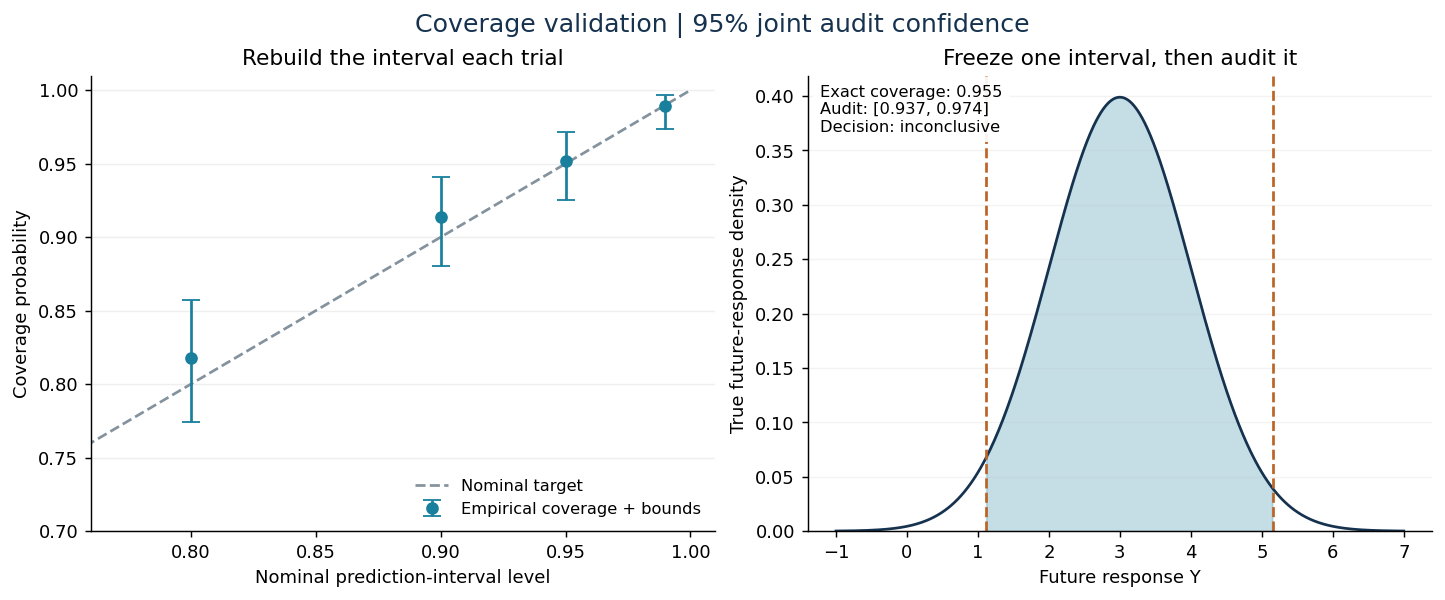

In [11]:
# Two targets: repeated construction on the left, one frozen interval on the right.
navy, blue, amber = "#16324f", "#187f9c", "#bc6426"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
ax = axes[0]
observed = np.array([c.empirical_coverage for c in procedure_certificates])
errors = np.array([[c.empirical_coverage-c.lower for c in procedure_certificates],
                   [c.upper-c.empirical_coverage for c in procedure_certificates]])
ax.plot([0, 1], [0, 1], "--", color="#83929d", label="Nominal target")
ax.errorbar(nominal_levels, observed, yerr=errors, fmt="o", color=blue,
            capsize=5, markersize=6, label="Empirical coverage + bounds")
ax.set(xlabel="Nominal prediction-interval level", ylabel="Coverage probability",
       title="Rebuild the interval each trial")
ax.set_xlim(max(0, min(nominal_levels)-0.04), min(1.01, max(nominal_levels)+0.03))
ax.set_ylim(max(0, min(0.7, min(c.lower for c in procedure_certificates)-0.025)), 1.01)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.2)

ax = axes[1]
sigma = model["sigma"]
if sigma > 0:
    x = np.linspace(min(true_mean-4*sigma, fixed_lower),
                    max(true_mean+4*sigma, fixed_upper), 700)
    density = np.exp(-0.5*((x-true_mean)/sigma)**2) / (sigma*np.sqrt(2*np.pi))
    ax.plot(x, density, color=navy)
    ax.fill_between(x, 0, density, where=(fixed_lower <= x) & (x <= fixed_upper),
                    color=blue, alpha=0.25)
    ax.set_ylabel("True future-response density")
else:
    ax.axvline(true_mean, color=navy, lw=3)
    ax.set_xlim(true_mean-1, true_mean+1)
    ax.set_ylabel("Point mass at the true mean")
ax.axvline(fixed_lower, color=amber, ls="--")
ax.axvline(fixed_upper, color=amber, ls="--")
ax.set(xlabel="Future response Y", title="Freeze one interval, then audit it")
ax.text(0.02, 0.98,
        f"Exact coverage: {fixed_exact:.3f}\n"
        f"Audit: [{fixed_certificate.lower:.3f}, {fixed_certificate.upper:.3f}]\n"
        f"Decision: {fixed_certificate.status}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.92})
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.15)
fig.suptitle(f"Coverage validation | {1-global_delta:.0%} joint audit confidence",
             fontsize=14, color=navy)
plt.show()
plt.close(fig)


### Precision at a stipulated observed proportion

The next figure holds the hypothetical ratio $S/N=0.95$ fixed and increases
$N$. It compares the two formulas using the procedure group's budget. It is
not based on additional audit observations and does not estimate the probability
of passing a test. The lower bounds approach $0.95$ from below.


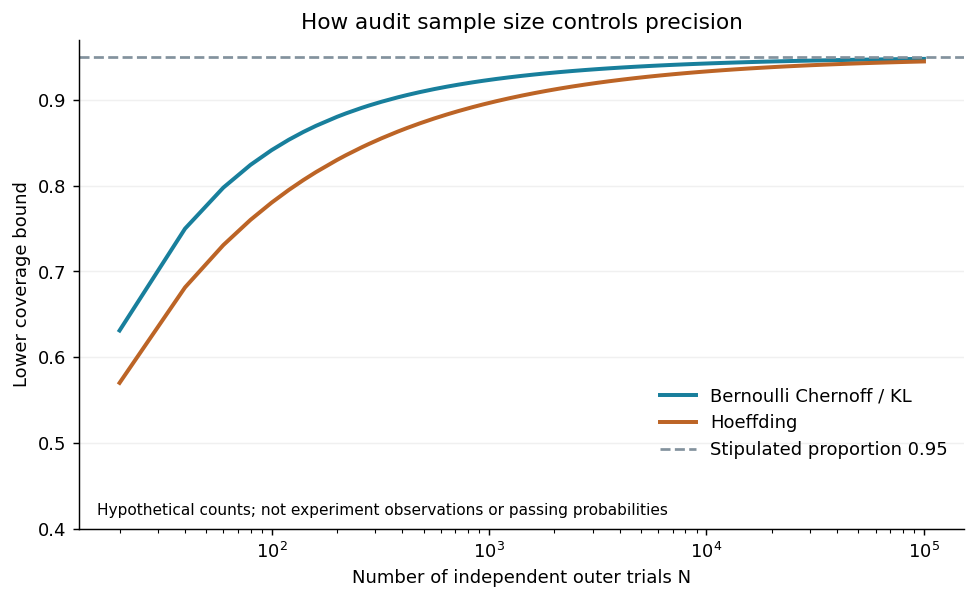

In [12]:
# These counts are hypothetical; this cell performs no new statistical audit.
# N is a multiple of 20, so k/N = 19/20 = 0.95 exactly as a rational number.
sample_sizes = np.unique(np.rint(np.geomspace(1, 5000, 65)).astype(int)) * 20
lower_curves = {}
for bound_method in ("kl", "hoeffding"):
    lower_curves[bound_method] = [
        coverage_certificate(
            19*(int(size)//20), int(size), delta=procedure_delta,
            num_claims=len(nominal_levels), method=bound_method,
        ).lower
        for size in sample_sizes
    ]
fig, ax = plt.subplots(figsize=(7.4, 4.5), constrained_layout=True)
ax.semilogx(sample_sizes, lower_curves["kl"], color=blue, lw=2.2,
            label="Bernoulli Chernoff / KL")
ax.semilogx(sample_sizes, lower_curves["hoeffding"], color=amber, lw=2.2,
            label="Hoeffding")
ax.axhline(0.95, color="#83929d", ls="--", label="Stipulated proportion 0.95")
ax.set(xlabel="Number of independent outer trials N", ylabel="Lower coverage bound",
       title="How audit sample size controls precision", ylim=(0.4, 0.97))
ax.text(0.02, 0.03, "Hypothetical counts; not experiment observations or passing probabilities",
        transform=ax.transAxes, fontsize=8.5)
ax.legend(loc="lower right", bbox_to_anchor=(1, 0.11), frameon=False)
ax.grid(axis="y", alpha=0.18)
plt.show()
plt.close(fig)


### 3.6 Two targets, one declared total error budget

The runner demonstrates both an average over newly constructed intervals and
coverage of one frozen interval. With total budget $\delta$, it allocates
$\delta/2$ to the four-level procedure audit and $\delta/2$ to the frozen-interval
audit. Within the first group the certificate's $K=4$ correction is applied.

If $E_1$ and $E_2$ are the two group success events, then

$$
\Pr(E_1^c\cup E_2^c)
\le \delta/2+\delta/2=\delta.
$$

For the second group, construction of the displayed interval precedes its
independent validation. Its guarantee first holds conditional on that
constructed interval; averaging over the interval preserves the same failure
bound. This justifies the combined statement. Printing a separate 95% result
for each group and calling the whole report 95% would not justify it.

For the frozen interval, the Gaussian model supplies an exact CDF calculation
as an additional benchmark. The unknown-coverage theorem does not use that
benchmark. Seeing the theoretical coverage outside a nominal band on a rare
run is compatible with a confidence procedure; do not rerun until it lands
inside and then report the chosen run as if unselected.


### 3.7 What the tests establish

The test suite includes:

- endpoint and monotonicity checks for KL inversion;
- exact finite binomial sums of noncoverage probabilities on a fixed grid;
- tests that more claims or higher confidence widen the intervals;
- numerical agreement of fast OLS with explicit rowwise regression;
- notebook integration tests that catch missing certificate returns;
- reproducibility and smoke checks for the experiment report.

For a true Bernoulli probability $p$, the deterministic probability check sums

$$
\sum_{s=0}^{N}\mathbf1\{p\notin[L(s),U(s)]\}
{N\choose s}p^s(1-p)^{N-s}
$$

and verifies that it is at most the allocated budget. This is more informative
than a flaky test that repeatedly samples random audits. It still checks only
selected parameters and floating-point arithmetic. The all-parameter result
comes from the proof in Chapter 2.


Run the following deterministic checks directly in this notebook.
They enumerate finite binomial outcomes, verify endpoint behavior and multiple-claim
budgets, and check the exact Gaussian benchmark and the noiseless simulation.
No test framework, repository test directory, or shell command is needed.


In [13]:
# Deterministic numerical checks support, but do not replace, Chapter 2's proof.
for bound_method in ("kl", "hoeffding"):
    zero = coverage_certificate(0, 100, method=bound_method)
    one = coverage_certificate(100, 100, method=bound_method)
    assert zero.lower == 0.0 and one.upper == 1.0
    baseline = coverage_certificate(95, 100, delta=0.05, method=bound_method)
    multiple = coverage_certificate(95, 100, delta=0.05, num_claims=10,
                                    method=bound_method)
    assert multiple.lower <= baseline.lower <= baseline.upper <= multiple.upper

# Sum exact binomial probabilities instead of running a flaky random test.
checked = 0
for bound_method in ("kl", "hoeffding"):
    for trials in (1, 5, 12, 30):
        intervals = [coverage_certificate(s, trials, delta=0.05, num_claims=4,
                                           method=bound_method)
                     for s in range(trials+1)]
        for true_p in (0.0, 0.01, 0.2, 0.5, 0.9, 0.99, 1.0):
            missed_probability = math.fsum(
                math.comb(trials, s)*true_p**s*(1-true_p)**(trials-s)
                for s, interval in enumerate(intervals)
                if true_p < interval.lower or true_p > interval.upper
            )
            assert missed_probability <= 0.05/4 + 1e-13
            checked += 1

assert gaussian_interval_coverage(3, 3, mean=3, sigma=0) == 1.0
assert gaussian_interval_coverage(0, 2, mean=3, sigma=0) == 0.0
np.testing.assert_allclose(
    gaussian_interval_coverage(-1.96, 1.96, mean=0, sigma=1),
    0.950004209703559, rtol=0, atol=1e-14,
)
noiseless = audit_procedure(np.random.default_rng(37), trials=5, R=10, n=4,
                            sigma=0, nominal_levels=[0.8, 0.95])
assert all(c.successes == 5 and c.trials == 5 for c in noiseless)
try:
    coverage_certificate(3.5, 10)
except ValueError:
    pass
else:
    raise AssertionError("Fractional successes must not be accepted as binomial counts")
print(f"All checks passed, including {checked} deterministic binomial-coverage cases.")


All checks passed, including 56 deterministic binomial-coverage cases.


### 3.8 Changing the experiment responsibly

Choose $N$, $R$, the candidate levels, the target, and the error budget before
inspecting the audit. Increase $R$ if you want a different, less noisy interval
constructor. Increase $N$ if you need a more precise estimate of the current
constructor's coverage. They solve different problems.

If an audit motivates changing the constructor, treat those observations as
development data. Freeze the new design and run a fresh audit, with a budget
appropriate to any combined claim you plan to make. To inspect accumulating
results and stop adaptively, use a bound valid simultaneously over time; the
next chapter derives a simple version.


<a id="chapter-4"></a>
## 4. Extensions, dependence, and the limits of a certificate

The preceding chapters establish a finite-sample guarantee for a fixed
validation protocol. This chapter asks how that guarantee changes when we
freeze one interval, predict an image, compare methods, or stop an experiment
early. Start with [the probability being estimated](#chapter-1)
and [the concentration theorem](#chapter-2).

Throughout, logarithms are natural, $0<\delta<1$ is a failure budget, and
training and tuning are completed independently of the validation data unless
explicitly stated otherwise. Independence is a property of the experimental
design; the certificate cannot verify it from a success count.


### 4.1 A random procedure and one frozen interval answer different questions

Let $A$ contain the randomness used to construct an interval $I(A)$. Let $Y$
be an independent future response from the population of interest. Define

$$
q(a)=\Pr_Y\{Y\in I(a)\},
\qquad
p_{\mathrm{procedure}}=\Pr_{A,Y}\{Y\in I(A)\}=\mathbb E_A q(A).
$$

There are two valid experiments:

1. **Reconstruct on every trial.** Draw independent pairs $(A_i,Y_i)$ and
   record $C_i=\mathbf 1\{Y_i\in I(A_i)\}$. These are independent Bernoulli
   variables with mean $p_{\mathrm{procedure}}$.
2. **Freeze once.** Construct $A_\star$ independently of the audit, then draw
   fresh independent $Y_1,\ldots,Y_N$. Conditional on $A_\star=a$, the indicators
   $C_i=\mathbf 1\{Y_i\in I(a)\}$ are independent Bernoulli variables with mean
   $q(a)$.

For the second experiment, let $[L_N,U_N]$ be either confidence interval from
Chapter 2 with one claim. Conditional validity says, for almost every $a$,

$$
\Pr\{q(A_\star)\in[L_N,U_N]\mid A_\star=a\}\ge 1-\delta.
$$

Taking expectations gives the same unconditional confidence guarantee for
the **random target** $q(A_\star)$. It does not give a confidence interval for
$p_{\mathrm{procedure}}$.

For a sharp example, let $Y$ be uniform on $[0,1]$. A randomized procedure
returns $[0,1]$ with probability $0.95$ and $[2,3]$ otherwise. Its average
coverage is $0.95$, while every realized interval has coverage either one or
zero. A certificate for the average cannot tell you which interval was drawn.

Reusing one random fitted model across all trials is therefore compatible
with a **conditional certificate for that fitted model**. Averaging over
model fitting requires repeating that fitting step independently. Do not
silently switch targets halfway through an experiment.


### 4.2 Images: choose the independent unit before counting successes

Suppose a fixed procedure produces intervals $I_j(X)$ for the $d$ coordinates
of an image $Y=(Y_1,\ldots,Y_d)$ given an input $X$. Draw independent images
$(X_i,Y_i)$, $i=1,\ldots,N$, from the target distribution. Any fresh procedural
randomness must also be independent between images; a shared fitted model
can instead be conditioned on as above. Write

$$
C_{ij}=\mathbf 1\{Y_{ij}\in I_j(X_i)\}.
$$

Pixels within an image may be arbitrarily dependent. The following are three
different scientific questions.

#### Expected fraction of covered pixels

Define one observation per image:

$$
Z_i=\frac1d\sum_{j=1}^d C_{ij},
\qquad m=\mathbb E Z_i,
\qquad \widehat m=\frac1N\sum_{i=1}^N Z_i.
$$

The $Z_i$ are independent, identically distributed, and lie in $[0,1]$.
Consequently, with probability at least $1-\delta$,

$$
|\widehat m-m|\le \sqrt{\frac{\log(2/\delta)}{2N}}.
$$

There is also a binary-KL Chernoff bound, even though $Z_i$ is not Bernoulli.
Convexity gives, for every $z\in[0,1]$ and every real $\lambda$,

$$
e^{\lambda z}\le (1-z)+ze^\lambda,
\qquad
\mathbb E e^{\lambda Z_i}\le 1-m+me^\lambda.
$$

Multiply these moment bounds using independence, apply exponential Markov,
and optimize in $\lambda$. This gives

$$
\Pr\{\widehat m\ge a\}\le e^{-N\operatorname{kl}(a\Vert m)}
\quad(a>m),
$$

and the corresponding lower-tail bound for $a<m$. The same inversion as in
Chapter 2 therefore yields the valid interval

$$
\{q\in[0,1]:N\operatorname{kl}(\widehat m\Vert q)\le\log(2/\delta)\}.
$$

This is a concentration argument for bounded observations, **not an exact
binomial model**. The embedded [implementation](#certificate-implementation) accepts
integer Bernoulli counts. Do not represent this audit as $Nd$ independent
trials, or round $N\widehat m$ to fit that API. Implement a bounded-mean
interface if this target is needed.

#### Coverage at every coordinate

For a fixed coordinate, $C_{1j},\ldots,C_{Nj}$ are independent Bernoulli
variables of mean $p_j$. A union bound over coordinates gives

$$
\Pr\left\{\forall j:\left|\frac1N\sum_i C_{ij}-p_j\right|
\le\sqrt{\frac{\log(2d/\delta)}{2N}}\right\}\ge1-\delta.
$$

Thus simultaneous absolute precision $\epsilon$ requires at most the
sufficient count $N=\lceil\log(2d/\delta)/(2\epsilon^2)\rceil$ independent
images. The image count grows logarithmically with $d$; evaluating all pixels
still costs $Nd$ indicator evaluations. For $K$ predetermined procedures,
replace $d$ by $Kd$. Dependence between coordinates does not invalidate this
union bound.

#### Coverage of the entire image

Define instead

$$
W_i=\mathbf 1\{C_{ij}=1\text{ for every }j\},
\qquad p_{\mathrm{whole}}=\mathbb E W_i.
$$

These are $N$ Bernoulli trials, directly supported by the existing API.
Simultaneously knowing that every $p_j\ge0.95$ does **not** establish
$p_{\mathrm{whole}}\ge0.95$. The elementary implication is only

$$
p_{\mathrm{whole}}\ge
\max\left(0,1-\sum_{j=1}^d(1-p_j)\right).
$$

Conversely, if all pixel indicators in an image are identical, increasing
$d$ supplies no additional independent information at all. Pixel count and
independent sample count are different resources.


### A million identical pixels do not make a million trials

This deterministic calculation compares the correct image-level radius with
the invalid radius obtained by multiplying the independent sample count by
the number of identical pixels. No simulated coverage claim is made here.


In [14]:
independent_images, pixels_per_image = 100, 1_000_000
correct_radius = math.sqrt(math.log(2/0.05)/(2*independent_images))
incorrect_radius = math.sqrt(
    math.log(2/0.05)/(2*independent_images*pixels_per_image)
)
print("Valid image-level Hoeffding radius:", correct_radius)
print("Invalid radius obtained by counting dependent pixels:", incorrect_radius)
assert math.isclose(correct_radius/incorrect_radius, math.sqrt(pixels_per_image))


Valid image-level Hoeffding radius: 0.13581015157406195
Invalid radius obtained by counting dependent pixels: 0.00013581015157406194


### 4.3 Selecting a method after validation

Suppose $K$ candidates are fixed before the audit. Let $E$ be the event that
all their confidence intervals contain their respective true coverages.
Chapter 2 gives $\Pr(E)\ge1-\delta$ when the budget includes all $K$ candidates.
For **any** selection rule $\widehat k$ based on those audit results,

$$
E\ \Longrightarrow\quad
p_{\widehat k}\in[L_{\widehat k},U_{\widehat k}].
$$

One may therefore choose the narrowest candidate among those certified to
meet a predetermined minimum coverage. This establishes the coverage claim
for the selected candidate; it does not separately certify its expected
width. Any additional statistical width claims need appropriate bounds and
error allocation.

All candidates may use the same validation images, response draws, or other
random inputs. This dependence often makes comparisons less noisy.
Independence is needed across trials **within each fixed candidate**, not
between candidates. The union bound never multiplies probabilities.

The premise fails when the audit is used to construct unrestricted new
candidates. Consider $X\sim\mathrm{Uniform}[0,1]$ and the deterministic response
$Y=0$. After seeing audit inputs $X_1,\ldots,X_N$, define

$$
I_D(x)=
\begin{cases}
[-1,1],&x\in\{X_1,\ldots,X_N\},\\
[1,2],&\text{otherwise}.
\end{cases}
$$

Its empirical coverage is one. Its coverage on a fresh input is zero because
a finite set has uniform probability zero. Calling this “one candidate”
and setting $K=1$ after constructing it does not produce a valid certificate.
The candidate depends on the very observations being treated as independent
validation data.

Increasing $K$ after inspection cannot generally repair this problem: the
fixed-candidate tail bound may no longer hold for a newly created candidate.
A union bound protects a finite family fixed independently of the audit,
even when only some members are eventually examined. Otherwise use fresh
independent validation data or prove a stronger theorem controlling the
entire allowed adaptive procedure.


### 4.4 A simple certificate valid at every sample size

Repeatedly checking a fixed-$N$ interval and stopping as soon as it passes
changes the experiment. Here is an elementary repair.

Fix $K$ candidates and, for each candidate $k$, an infinite sequence of
independent Bernoulli trials with constant mean $p_k$. Sequences may depend
on each other. At time $t\ge1$, each candidate has its first $t$ trials. Set

$$
\delta_t=\frac{6\delta}{\pi^2t^2},
\qquad
b_t=\log\frac{2K}{\delta_t}
=\log\frac{\pi^2Kt^2}{3\delta}.
$$

Apply either Chapter 2 construction at time $t$, replacing $\delta$ by
$\delta_t$. The Hoeffding radius is

$$
r_t=\sqrt{\frac{b_t}{2t}},
$$

and the KL interval for candidate $k$ is

$$
[L_{k,t},U_{k,t}]
=\{q\in[0,1]:t\operatorname{kl}(\widehat p_{k,t}\Vert q)\le b_t\}.
$$

**Theorem.** With probability at least $1-\delta$, every interval contains
its target, simultaneously for every candidate and every positive time:

$$
\Pr\{\forall k\le K,\ \forall t\ge1:
p_k\in[L_{k,t},U_{k,t}]\}\ge1-\delta.
$$

**Proof.** At a fixed time, allocate $\delta_t/(2K)$ to each candidate and
each tail. The probability of any failure at that time is at most $\delta_t$.
Countable subadditivity and $\sum_{t\ge1}t^{-2}=\pi^2/6$ give

$$
\Pr\{\text{any failure at any time}\}
\le\sum_{t\ge1}\delta_t=\delta.
$$

No independence between times or candidates is used. $\square$

Consequently, stopping at any data-dependent finite time and selecting any
candidate preserves coverage of its reported confidence interval. The
procedure itself and its target distribution must stay fixed. This theorem
does not authorize retraining candidates on the growing audit.

For Bernoulli data, the fixed-time implementation can be used as a building
block:


In [15]:
import math

def anytime_certificate(successes, t, *, delta=0.05, num_claims=1):
    # t is this candidate's cumulative number of independent trials.
    delta_t = 6 * delta / (math.pi**2 * t**2)
    return coverage_certificate(
        successes, t, delta=delta_t, num_claims=num_claims,
        method="kl", target_coverage=0.95,
    )


The returned object's `delta` is the **local** budget $\delta_t$; the global
$\delta$ is justified by the theorem above. The same union argument also
allows different candidates to be inspected at different cumulative sample
counts, provided each candidate's underlying sequence satisfies the stated
assumptions. This is a standard union-bound construction, not a novel result.


### Separate sequential illustration

The next example has its own 5% time-uniform budget and a known simulation
probability $p=0.99$. It stops at the first certificate for the predeclared
target $0.95$, or at 3,000 trials. Stopping is permitted by the theorem just
proved. This demonstration is separate from the main experiment's joint budget.
There is no guarantee that it will certify before the cap.


In [16]:
sequential_rng = np.random.default_rng(812)
sequential_successes = 0
for t in range(1, 3001):
    sequential_successes += int(sequential_rng.random() < 0.99)
    sequential_result = anytime_certificate(sequential_successes, t, delta=0.05)
    if sequential_result.status == "certified":
        break
print(f"Stopped after {t} trials: {sequential_successes} successes; "
      f"[{sequential_result.lower:.4f}, {sequential_result.upper:.4f}]; "
      f"{sequential_result.status}")
print("This stopping rule used delta_t = 6*0.05/(pi**2*t**2), not repeated fixed-delta tests.")


Stopped after 656 trials: 650 successes; [0.9500, 0.9998]; certified
This stopping rule used delta_t = 6*0.05/(pi**2*t**2), not repeated fixed-delta tests.


### 4.5 What concentration cannot supply

A simulator certificate concerns the simulator's distribution. More simulated
trials reduce Monte Carlo error; they do not establish that the simulator
represents the physical experiment.

A possible transfer assumption makes the gap explicit. Let $P$ and $Q$ be
the complete trial distributions in simulation and reality, including any
randomness entering the coverage event $B$. If

$$
\operatorname{TV}(P,Q)=\sup_E|P(E)-Q(E)|\le\eta,
$$

then $Q(B)\ge P(B)-\eta$. A simulated lower confidence bound $L$ therefore
implies the real-world lower bound $\max(0,L-\eta)$ on the same confidence
event. The simulator audit does not estimate $\eta$; establishing that bound
is a separate scientific task.

Even exchangeability alone cannot replace trial independence. Draw one
latent $B\sim\mathrm{Bernoulli}(1/2)$ and set $C_i=B$ for every $i$. This
sequence is exchangeable, with every marginal mean equal to $1/2$, but

$$
\widehat p_N=B,
\qquad
\Pr\{|\widehat p_N-1/2|>1/4\}=1
$$

for every $N$. There is no concentration around the marginal mean as the
nominal sample size grows. A dependence model, independent experimental
replicates, or a different target is required.


### 4.6 Research directions left unresolved by this repository

These are extensions of this tutorial's implementation, not claims of new
theorems or assertions that the corresponding fields are unsolved:

- **Dependent physical observations:** specify a justified dependence model
  and derive a valid concentration bound with its parameters included.
- **Adaptive scientific iteration:** characterize permitted updates and
  control repeated reuse of validation data without silently treating new
  candidates as fixed.
- **Efficient sequential audits:** implement tighter confidence sequences
  and compare their required simulations with the elementary construction.
- **Simulator transfer:** obtain defensible discrepancy bounds for a stated
  physical experiment and propagate them to its coverage claim.
- **Useful high-dimensional intervals:** jointly assess width and the chosen
  coverage target, keeping average, coordinatewise, and whole-image coverage
  distinct.

Each direction begins by specifying the probability being certified and
identifying the independent information available to estimate it.


<a id="chapter-5"></a>
## 5. Exercises, solutions, and small projects

[Contents](#contents) · [Probability](#chapter-1) ·
[Concentration](#chapter-2) ·
[Implementation](#chapter-3) · [Extensions](#chapter-4)

Try each exercise before reading its solution. The first two sections answer
the exercises posed in the corresponding chapters; the last section contains
additional mathematical and programming tasks.


<a id="solutions-chapter-1"></a>
### Chapter 1: Probability and targets

#### 1. One interval or many intervals?

**Question.** Write the probability estimated by testing one constructed
interval against $N$ fresh responses, then by independently rebuilding the
interval on each of $N$ trials.

**Solution.** If $A_0$ denotes the first interval's construction randomness,
the first experiment is conditional on $A_0$ and estimates

$$
q(A_0)=\Pr_Y\{Y\in I(A_0)\mid A_0\}.
$$

The second estimates

$$
p=\Pr_{A,Y}\{Y\in I(A)\}=\mathbb E_A q(A).
$$

The original notebook uses the second protocol. The new runner demonstrates
both, with distinct validation data and declared error budgets. An average
of conditional probabilities need not describe every conditional probability.

#### 2. Marginal coverage need not hold at each query

**Question.** Define marginal and query-conditional coverage and construct a
counterexample to their equivalence.

**Solution.** For a fixed prediction procedure, let

$$
q(x)=\Pr\{Y\in I(X)\mid X=x\},\qquad
p=\Pr\{Y\in I(X)\}=\mathbb E q(X).
$$

Conditional probabilities are understood where a version is defined; claims
about every point require additional regularity or an explicit finite model.
Take $X\in\{0,1\}$ with $\Pr(X=0)=.99$ and deterministic $Y=0$. Use
$I(0)=[-1,1]$ and $I(1)=[1,2]$. Then $p=.99$ while $q(1)=0$.
A random-query audit estimates $p$; it does not establish $q(1)\ge.99$.

#### 3. Average coverage can hide disastrous realized intervals

**Question.** Construct a randomized interval procedure with average coverage
$.95$ whose output sometimes has zero coverage.

**Solution.** Let $Y$ be uniform on $[0,1]$. Independently of $Y$, output
$[0,1]$ with probability $.95$ and $[2,3]$ otherwise. The conditional coverage
of the output is either $1$ or $0$, while its expectation is $.95$.
Repeatedly reconstructing intervals measures the expectation. Freezing one
output and auditing it measures that output's conditional coverage.

#### 4. Derive the OLS prediction variance

**Question.** Prove that, conditional on the training design,
$\operatorname{Var}(\widehat\mu_\star\mid X)=\sigma^2h_X$.

**Solution.** Write $u_i=X_i-\bar X$ and $S_{xx}=\sum_i u_i^2$.
The slope error is

$$
\widehat\beta_1-\beta_1=\frac{\sum_i u_i\varepsilon_i}{S_{xx}}.
$$

Using $\widehat\mu_\star=\bar Y+\widehat\beta_1(x_\star-\bar X)$,

$$
\widehat\mu_\star-\mu_\star
=\sum_{i=1}^n w_i\varepsilon_i,
\qquad
w_i=\frac1n+\frac{(x_\star-\bar X)u_i}{S_{xx}}.
$$

Because $\sum_i u_i=0$,

$$
\sum_iw_i^2=\frac1n+\frac{(x_\star-\bar X)^2}{S_{xx}}=h_X.
$$

The errors are independent centered normal variables of variance $\sigma^2$
conditional on the design. A weighted sum is therefore normal with mean zero
and variance $\sigma^2\sum_i w_i^2$. Adding independent future noise gives
variance $\sigma^2(1+h_X)$, which explains the construction distribution.


<a id="solutions-chapter-2"></a>
### Chapter 2: Concentration and certification

#### 1. The lower-tail optimizer

**Question.** Derive the Chernoff optimizer for a threshold $a<p$.

**Solution.** For $t<0$, the event $\sum_iC_i\le Na$ implies
$\exp(t\sum_iC_i)\ge e^{tNa}$. Exponential Markov gives the same objective
$e^{-tNa}(1-p+pe^t)^N$. Its stationary point obeys

$$
e^{t_*}=\frac{a(1-p)}{p(1-a)}<1.
$$

Thus $t_*<0$, as required. The second derivative of the log moment generating
function is nonnegative, so this is the minimizer. Substitution yields
$e^{-N\operatorname{kl}(a\Vert p)}$. Endpoint cases follow by limits or
by direct evaluation of all-zero/all-one events.

#### 2. Why two bisections work

**Question.** Show that a KL sublevel set is an interval and determine its
endpoint cases. Which numerical bracket endpoints are conservative?

**Solution.** At a fixed empirical proportion $a\in(0,1)$,

$$
\partial_q\operatorname{kl}(a\Vert q)=\frac{q-a}{q(1-q)}.
$$

The function decreases to zero at $q=a$ and then increases, diverging at
both ends. A positive sublevel set is an interval whose endpoints are its
unique left and right roots. If $a=0$, the inequality is
$-N\log(1-q)\le b$, giving $[0,1-e^{-b/N}]$. If $a=1$, it is
$-N\log q\le b$, giving $[e^{-b/N},1]$.

For the lower root return the bracket endpoint farther toward zero; for the
upper root return the endpoint farther toward one. Those choices enlarge
the interval. They avoid a directional error in bracket selection, although
ordinary floating-point evaluation still has rounding error.

#### 3. Interpret 953 successes

**Question.** Compute Hoeffding and KL intervals for $S=953$, $N=1000$,
$K=4$, and $\delta=.05$. What calibration tolerance around $.95$ would contain
the KL interval?

**Solution.** Run:


In [17]:
for method in ("hoeffding", "kl"):
    c = coverage_certificate(953, 1000, delta=.05, num_claims=4,
                             method=method, target_coverage=.95)
    print(method, c.lower, c.upper, c.status)


hoeffding 0.9026255331778397 1.0 inconclusive
kl 0.9285716447496765 0.9713287774770121 inconclusive


Hoeffding gives approximately $[.90263,1]$; KL gives approximately
$[.92857,.97133]$. Neither certifies minimum coverage $.95$.
The smallest symmetric tolerance containing the KL interval is

$$
\tau_* = \max\{.95-L,U-.95\}\approx .02143.
$$

For example, a tolerance of $.022$ would contain the band. This is an
interpretation exercise, not a recommendation to choose the scientific
acceptance tolerance after seeing the audit. A prespecified $.022$ tolerance
would support a calibration-within-tolerance decision on this confidence
event. The confidence set itself remains valid without a threshold; reporting
its endpoints directly avoids pretending an acceptance rule was prespecified.

#### 4. Power for all candidates

**Question.** Suppose every true coverage satisfies $p_k\ge p_{0,k}+\gamma$
for a common $\gamma>0$. Find a sufficient sample size for all Hoeffding
minimum-coverage certificates to pass with probability at least $1-\eta$.

**Solution.** The first union bound, over $2K$ confidence tails, sets
$r=\sqrt{\log(2K/\delta)/(2N)}$. A separate union bound on the probabilities
of unfavorable empirical fluctuations gives

$$
\Pr\left\{\forall k:\widehat p_k\ge
p_k-\sqrt{\frac{\log(K/\eta)}{2N}}\right\}\ge1-\eta.
$$

On that event, each lower confidence bound reaches its target whenever

$$
\sqrt{\frac{\log(2K/\delta)}{2N}}+
\sqrt{\frac{\log(K/\eta)}{2N}}\le\gamma.
$$

A sufficient integer sample size is therefore

$$
N\ge\left\lceil
\frac{(\sqrt{\log(2K/\delta)}+\sqrt{\log(K/\eta)})^2}{2\gamma^2}
\right\rceil.
$$

The parameter $\delta$ controls false claims; $\eta$ controls non-passing under
a positive-margin alternative. They have different roles. At $\gamma=0$,
this argument offers no high-probability passing guarantee.


### Further mathematical and programming exercises

#### 1. One image with a million identical pixels

**Task.** Let all $d$ coverage indicators in image $i$ equal the same
Bernoulli variable $B_i$. Compare the image-average coverage estimator with
an incorrect calculation treating $Nd$ pixels as independent.

**Solution.** The empirical pixel average is exactly
$N^{-1}\sum_iB_i$. Its variance is $p(1-p)/N$, independent of $d$. Treating
pixels as independent would incorrectly divide this variance by $d$, or
shrink a Hoeffding radius by $\sqrt d$. Test code should preserve the image
axis and aggregate within each image before applying a bounded-mean theorem.

#### 2. Rare failures and the cost of certification

**Task.** With no observed failures, derive the trial count needed to certify
coverage at least $1-\alpha$ and explain what this does not guarantee.

**Solution.** The two-sided KL lower bound is
$\exp[-\log(2K/\delta)/N]$. It is at least $1-\alpha$ if

$$
N\ge\frac{\log(2K/\delta)}{-\log(1-\alpha)}.
$$

As $\alpha\downarrow0$, $-\log(1-\alpha)\sim\alpha$, giving a count of
order $\log(K/\delta)/\alpha$. The calculation assumes all trials succeeded.
It does not promise that they will: if the true coverage is $p$, the
probability of observing all successes is $p^N$.

#### 3. Implement a valid stopping rule

**Task.** Use the wrapper in Chapter 4, stop at the first time its lower
bound exceeds a fixed target, and explain the guarantee even though the
stopping time depends on the data.

**Solution.** Use $\delta_t=6\delta/(\pi^2t^2)$ for the certificate at
cumulative trial count $t$. With probability at least $1-\delta$, all
reported bands contain their target probabilities for every $t$. On that
single event any finite data-dependent selection of a time also has a valid
band. There is no promise that the stopping time is finite. Replacing
$\delta_t$ by the same fixed $\delta$ on every inspection loses this proof.

#### 4. Add a bounded-mean API

**Task.** Design an interface for image-average coverage observations in
$[0,1]$ without converting them to binomial counts.

**Solution sketch.** Accept the number of independent images $N$ and their
empirical mean $\widehat m$, validate $N\ge1$ and $\widehat m\in[0,1]$,
and invert $N\operatorname{kl}(\widehat m\Vert q)\le\log(2K/\delta)$.
The proof is the bounded-observation moment inequality in Chapter 4. Keep
this API distinct from integer Bernoulli counts, and do not call an exact
binomial interval routine on fractional successes. Add tests for deterministic
fractional observations, endpoint means, and the pixel-dependence example.
This is a proposed extension, not an implemented public function here.

#### 5. Build a comparison that remains valid after selection

**Task.** Predeclare several interval-width multipliers and select the
narrowest candidate whose coverage is certified. Explain which claim is
supported and what must be done if no candidate passes.

**Solution sketch.** Include every candidate in the simultaneous budget.
On the event that all bands are valid, whichever passing candidate is selected
has true coverage above the target. If none passes, report no certified
candidate; do not lower the target or invent a new multiplier using the same
audit and pretend it was one fixed candidate. If expected width is also to
be certified, define its statistical target and supply an appropriate bound.

#### 6. Explain the Gaussian benchmark's limits

**Task.** Why can the runner compute the exact coverage of a frozen interval,
and why is that not already a certificate for an unknown physical system?

**Solution.** Here the response distribution and its true parameters are
explicitly supplied. For a fixed interval its probability is a Gaussian CDF
difference. In a physical system, those parameters and even the model family
may be uncertain. Simulator agreement does not establish their correctness.
Chapter 4's total-variation transfer statement shows exactly where an
additional justified model-discrepancy bound would enter.


<a id="references"></a>
## Provenance and original references

The starting simulation is [payal101/UQ_1](https://github.com/payal101/UQ_1),
source snapshot `eaa3830` ("Revise README for clarity and structure"). Its
normal-design linear-regression model, OLS fit, and Monte Carlo interval
construction are retained in distribution. The embedded simulator vectorizes
the independent fits and uses a documented shared-randomness audit protocol.
The historical original-notebook counts are explicitly separated above.

The explanatory chapters and embedded implementation were assembled into this
standalone notebook by `scripts/build_tutorial_notebook.py`. The builder reads
repository sources at build time; this notebook needs no companion files at run
time. Embedded source fingerprints are:

- `validation.py` SHA-256: `0475d2dc50bcd1a193cc351cfaf717b7288ebe3d48780e48bed42c0f814824a2`
- `simulation.py` SHA-256: `d4bfffac6121f3004ec571c9974db8d5fca38753cb3e717b708bd0630dfb6e0c`

These are classical concentration arguments and teaching demonstrations, not
claims of new theorems. The numerical examples use synthetic data only. No license
file was present in the original source snapshot; this notebook does not assign
a new license to that source material. Preserve its attribution.

Original mathematical references:

- W. Hoeffding (1963), [Probability Inequalities for Sums of Bounded Random
  Variables](https://doi.org/10.1080/01621459.1963.10500830), *Journal of the
  American Statistical Association* 58(301), 13–30.
- H. Chernoff (1952), [A Measure of Asymptotic Efficiency for Tests of a
  Hypothesis Based on the Sum of Observations](https://doi.org/10.1214/aoms/1177729330),
  *Annals of Mathematical Statistics* 23(4), 493–507.

To reproduce the tutorial, restart the kernel and run from the setup cell to
the end. To investigate a new model or target, decide the new protocol first
and allocate independent audit data and an appropriate confidence budget.
